# Triple-RSI — is a 90% win rate as good as it sounds?
### A viral 'buy the oversold bounce' recipe, tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![A_90%25_win--rate_money_machine%3F: Busted](https://img.shields.io/badge/A_90%25_win--rate_money_machine%3F-Busted-8b949e?style=flat-square)

A strategy doing the rounds on finance Twitter: the **Triple RSI**, marketed as a **90% win rate** on the S&P 500. The recipe stacks four conditions (three of them on the 5-day RSI), and when they all line up you buy, then sell a few days later when the RSI recovers. Ninety percent of trades make money. Sounds like a money machine. This notebook asks the only two questions that matter: *is the signal real, and is a 90% win rate actually worth anything?*

> **This is the plain-language layer.** Want the t-stats, the random-control and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_rsi import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "DIA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def fetch(t):
    return data.fetch_daily(t, fetch=False)

def run_one(t, entry="close", cost=0.0, trend_sma=200, seed=None):
    b = fetch(t)
    sig = st.triple_rsi_entries(b, trend_sma=trend_sma)
    dirs = st.random_directions(int(sig.sum()), seed=seed) if seed is not None else None
    return st.run_trades(b, sig, rsi_exit=50.0, cost_bps=cost, entry=entry, random_dirs=dirs)

def run_all(entry="close", cost=0.0, trend_sma=200, seed=None):
    return pd.concat([run_one(t, entry, cost, trend_sma, seed) for t in TICKERS],
                     ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the oversold bounce real? | **Yes.** On SPY it earns **+133 bps per trade** (HAC *t* = +5.07) and survives an honest next-open fill — a genuine, durable signal. |
| Is the 90% win rate real? | **Basically yes — 88%.** But that's the wrong number: on a pure coin flip the *same* exit already wins 62% with a **losing** average. |
| Can you get rich on it? | **No.** It trades **3.5 times a year** and sits in cash ~93% of the time, compounding to ~+4.7%/yr — about **half** of just holding the index (+10.8%/yr). |
| So what is it? | A real but **capital-starved** signal — a fine overlay, a poor stand-alone 'system'. The headline sells the win rate because the *returns* don't sell. |

> The Triple-RSI is not a scam — the signal is real. But '90% win rate' is marketing sleight-of-hand: it points at the one flattering number and away from the one that matters (how much money, vs just buying and holding).

## 1 · The claim

> *"The Triple RSI strategy has few trades but a solid **90% win rate**. Buy SPY at the close when: the 5-day RSI is below 30, **and** it's down for the third day in a row, **and** it was below 60 three days ago, **and** the close is above the 200-day moving average. Sell at the close when the 5-day RSI crosses above 50."*

— QuantifiedStrategies.com, *Triple RSI Trading Strategy: Boost Your Win Rate to 90%*

The idea rests on something real: at a few-day horizon, beaten-down index prices tend to **bounce**. An RSI below 30 that's been falling for days is the market equivalent of a short, sharp panic — and panics often overshoot. The bet is that the snap-back pays.

## 2 · So what?

Two things make this one worth a careful look. First, the underlying effect (short-term mean reversion) is *real* — the desk has already stamped its cousin, the Connors RSI(2) system, as a genuine signal ([Study 75 — Knee-Jerk](../../75-knee-jerk/)). So this isn't pure folklore. Second, the **'90% win rate'** headline is a perfect specimen of a very common trap: a number that's technically true and almost entirely useless. If we can show *why* it's useless, that lesson transfers to every 'high win rate' system you'll ever be pitched.

## 3 · How would we even know?

Three checks keep us honest:

1. **Race it against a coin.** Take every Triple-RSI entry, but on half the trades go *random* direction instead of always buying. If the signal means something, it beats the coin.
2. **Pay an honest fill.** The recipe buys at the *same close* it uses to spot the signal — slightly optimistic. We re-run buying at the *next* day's open to make sure the edge isn't a measurement trick.
3. **Interrogate the win rate.** We run the exact same exit rule on a **pure random walk** — a tape with no signal at all — and see what win rate it prints. Spoiler: a high one.

Tape: SPY daily bars back to 1993 (plus QQQ, IWM, DIA for breadth).

## 4 · The teardown — let's actually look

**First: does it beat a coin?** The Triple-RSI rule vs a random-direction entry on the same bars, gross:

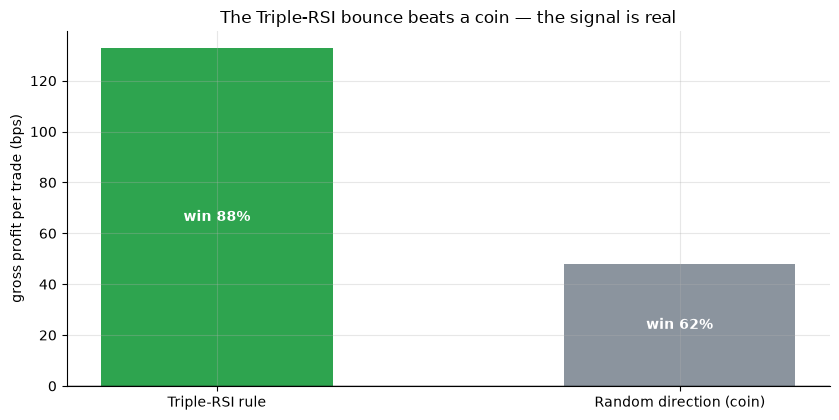

Rule: +132.8 bps   Coin: +47.9 bps   Excess: +84.9 bps


In [2]:
if HAVE_REAL:
    led = run_one('SPY'); rand = run_one('SPY', seed=301)
    rule_m = st.summarize(led,'ret_gross')['mean_bps']
    rand_m = st.summarize(rand,'ret_gross')['mean_bps']
    rule_w = st.summarize(led,'ret_gross')['win_rate']*100
    rand_w = st.summarize(rand,'ret_gross')['win_rate']*100
else:
    rule_m, rand_m = 132.8, 47.9
    rule_w, rand_w = 88.1, 61.9
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Triple-RSI rule', 'Random direction (coin)'],
           [rule_m, rand_m], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The Triple-RSI bounce beats a coin — the signal is real')
for bar_, w in zip(b, [rule_w, rand_w]):
    ax.annotate(f'win {w:.0f}%', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()/2), ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Rule: {rule_m:+.1f} bps   Coin: {rand_m:+.1f} bps   Excess: {rule_m-rand_m:+.1f} bps')

The rule earns **+133 bps/trade** at an **88%** win rate; the coin earns +48 bps. The signal adds **+85 bps** of real edge on top of the base drift. Good — this isn't noise.

**Now the punchline. Here's the same exit rule run on a pure random walk** — a tape engineered to have *no signal whatsoever*. What win rate does a strategy with zero edge print?

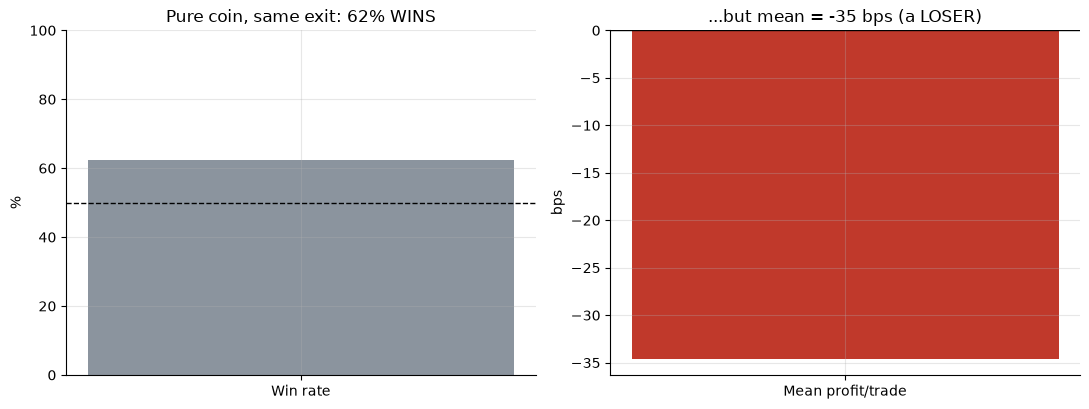

No-signal tape: win 62.3%  mean -34.6 bps  skew -1.65


In [3]:
b0, _ = data.synthetic_daily(n_days=8000, reversion=0.0, seed=301)
sig0 = st.triple_rsi_entries(b0, trend_sma=None)
s0 = st.summarize(st.run_trades(b0, sig0, rsi_exit=50.0, cost_bps=0, entry='close'), 'ret_gross')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(['Win rate'], [s0['win_rate']*100], color=GREY, width=.45)
a1.axhline(50, ls='--', c='k', lw=1); a1.set_ylim(0, 100)
a1.set_ylabel('%'); a1.set_title(f"Pure coin, same exit: {s0['win_rate']*100:.0f}% WINS")
a2.bar(['Mean profit/trade'], [s0['mean_bps']], color=RED, width=.45)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('bps')
a2.set_title(f"...but mean = {s0['mean_bps']:+.0f} bps (a LOSER)")
plt.tight_layout(); plt.show()
print(f"No-signal tape: win {s0['win_rate']*100:.1f}%  mean {s0['mean_bps']:+.1f} bps  skew {s0['skew']:+.2f}")

There it is. On a tape with **no edge at all**, the 'take the bounce' exit still wins **~62% of trades** — while *losing money on average* (-35 bps). The trick is the exit: you sell winners the instant they bounce (lots of small wins) and hold losers as they bleed (a few big losses). A high win rate is the **shape of the exit**, not the **quality of the signal**. So '90% wins' tells you almost nothing — you have to look at the average and the rare big losses (SPY's worst trade: -7.4%).

**Last: even with a real signal, can you get rich on it?** Here's the catch the headline never mentions — how *often* it trades, and how that stacks up against simply holding SPY:

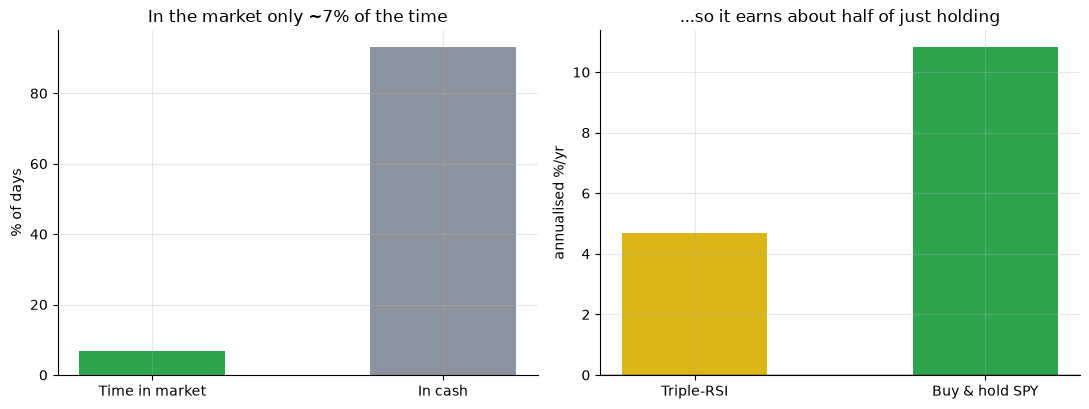

3.5 trades/yr, ~7% in market, ~4.7%/yr vs B&H 10.8%/yr


In [4]:
if HAVE_REAL:
    led = run_one('SPY'); n = len(led); hold = led['days_held'].mean()
    spy = fetch('SPY'); yrs = (spy.index[-1]-spy.index[0]).days/365.25
    tpy = n/yrs; pim = led['days_held'].sum()/len(spy)*100
    ann = st.summarize(led,'ret_gross')['mean_bps']*tpy/100
    bh = ((spy['close'].iloc[-1]/spy['close'].iloc[0])**(1/yrs)-1)*100
else:
    tpy, pim, ann, bh = 3.5, 6.8, 4.69, 10.8
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(['Time in market','In cash'], [pim, 100-pim], color=[GREEN, GREY], width=.5)
a1.set_ylabel('% of days'); a1.set_title(f'In the market only ~{pim:.0f}% of the time')
a2.bar(['Triple-RSI','Buy & hold SPY'], [ann, bh], color=[AMBER, GREEN], width=.5)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('annualised %/yr')
a2.set_title('...so it earns about half of just holding')
plt.tight_layout(); plt.show()
print(f'{tpy:.1f} trades/yr, ~{pim:.0f}% in market, ~{ann:.1f}%/yr vs B&H {bh:.1f}%/yr')

**~4 trades a year.** The strategy is in the market only ~7% of the time, so even a fat +133 bps/trade compounds to only ~+4.7%/yr — while SPY buy-and-hold returned +10.8%/yr. The '90% win rate machine' earns **half of doing nothing but holding the index.**

## 5 · The verdict

- **Signal — Real.** +133 bps/trade on SPY (*t* = +5.07); beats a coin by +85 bps; survives an honest fill. The bounce is genuine.
- **Tradability — Fragile.** Not because of costs (it shrugs those off) but because of **capacity**: 4 trades/yr, ~7% in the market, ~+4.7%/yr vs the index's +10.8%.
- **A 90% win-rate money machine? — Busted.** The 88% win rate is real but meaningless as an edge: a pure coin under the same exit wins 62% and *loses* money. Win rate is the shape of the exit, not the quality of the signal.

## 6 · Could you actually trade it?

Costs are not the problem here — with so few trades, even a generous round-trip fee barely registers:

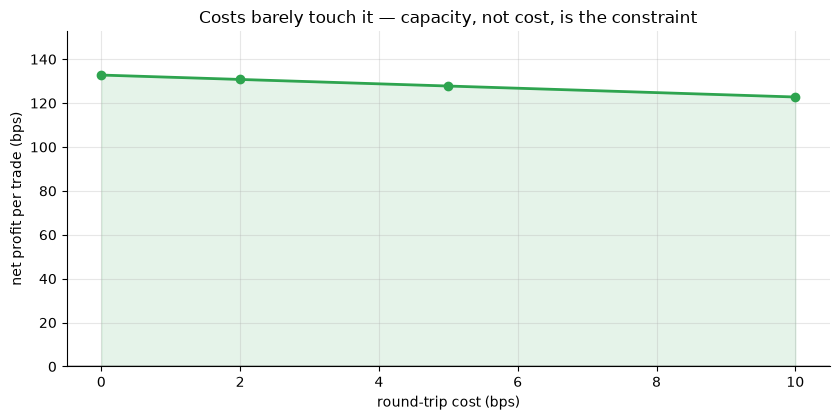

Even at 10 bps the per-trade edge is huge — the problem is there are only ~3.5 trades/yr.


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    spy = fetch('SPY'); sig = st.triple_rsi_entries(spy)
    net = [st.summarize(st.run_trades(spy, sig, rsi_exit=50.0, cost_bps=c, entry='close'),
                        'ret_net')['mean_bps'] for c in costs]
else:
    net = [132.8, 130.8, 127.8, 122.8]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, color=GREEN, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_ylim(0, max(net)*1.15)
ax.set_title('Costs barely touch it — capacity, not cost, is the constraint')
plt.tight_layout(); plt.show()
print('Even at 10 bps the per-trade edge is huge — the problem is there are only ~3.5 trades/yr.')

At 10 bps the edge is still **+123 bps/trade** (*t* = +4.69). Unlike the desk's pure mirages, this one doesn't die at the first dollar of cost — it's genuinely *fragile* rather than fake. The honest pitch isn't 'a 90% win-rate system'; it's 'a small, real, occasional overlay on top of something you're already holding.'

## 7 · Going further

- **The signal's honest cousin.** [Study 75 — Knee-Jerk](../../75-knee-jerk/) is the Connors RSI(2) system — the same oversold-bounce family, but it fires ~24 times a year instead of 3.5. Triple-RSI's extra filters *buy* a higher win rate by *throwing away* trades.
- **Where the win-rate illusion was first dissected.** [Study 72 — Loaded-Dice](../../72-loaded-dice/) showed a 93.5% win rate on pure noise via a tiny-take-profit exit. Triple-RSI is the honest twin: same illusion, but a real signal underneath.
- **Could you fix the capacity problem?** Dropping the 200-SMA filter triples the trades (to ~8/yr) and the signal holds — but you're still capital-starved. The real fix is to run it cross-sectionally over many names, not as a single-ticker timer.

*Think the 90% is the whole story? Fork this, change the exit, and show the win rate surviving once you measure the thing that actually pays the bills — the mean.*